In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_cleaned_v2.csv', index_col = False)

In [3]:
df.shape

(3790, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3790 entries, 0 to 3789
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3790 non-null   str    
 1   society              3789 non-null   str    
 2   sector               3790 non-null   str    
 3   price_in_cr          3772 non-null   float64
 4   price_per_sqft       3772 non-null   float64
 5   area                 3772 non-null   float64
 6   areaWithType         3790 non-null   str    
 7   bedRoom              3790 non-null   int64  
 8   bathroom             3790 non-null   int64  
 9   balcony              3790 non-null   str    
 10  floorNum             3771 non-null   float64
 11  facing               2694 non-null   str    
 12  agePossession        3790 non-null   str    
 13  super_built_up_area  1912 non-null   float64
 14  built_up_area        1728 non-null   float64
 15  carpet_area          1939 non-null   float64
 16 

In [5]:
df.duplicated().sum()

np.int64(126)

In [6]:
df.drop_duplicates(inplace = True)

### property_type

<Axes: xlabel='property_type'>

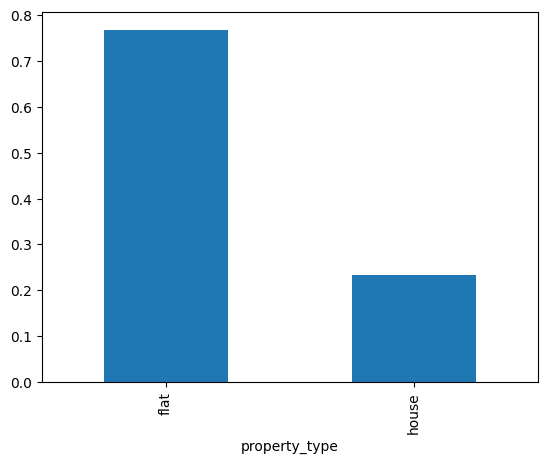

In [7]:
(df['property_type'].value_counts()/df.shape[0]).plot(kind= 'bar')

In [8]:
df['property_type'].isnull().sum()

np.int64(0)

Observations
- flats dominate the numbers. More than 75% are flats
- no missing values in property_type

### society

In [9]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
bhawna cghs                               1
rattan vihar rajendra park                1
huda plots                                1
global height                             1
on request                                1
Name: count, Length: 668, dtype: int64

In [10]:
(df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum() <= 0.50).value_counts()

proportion
False    595
True      72
Name: count, dtype: int64

- a large chunk of societies belong to independent society. 
- out of other societies, 50% of them belong to 72 societies and remaining 595 societies frequency is very low

In [11]:
# creating a bins in society columns to understand the number of properties in different societies

society_counts = df['society'].value_counts()

society_frequency_bins = {
    'Very High (>100)': (society_counts > 100).sum(),
    'High (50-100)': ((society_counts >= 50) & (society_counts <= 100)).sum(),
    'Avg (10-49)': ((society_counts >= 10) & (society_counts < 50)).sum(),
    'Low (2-9)': ((society_counts > 1) & (society_counts < 10)).sum(),
    'Very Low (=1)': (society_counts == 1).sum()
}

society_frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Avg (10-49)': np.int64(92),
 'Low (2-9)': np.int64(272),
 'Very Low (=1)': np.int64(301)}

<Axes: xlabel='society'>

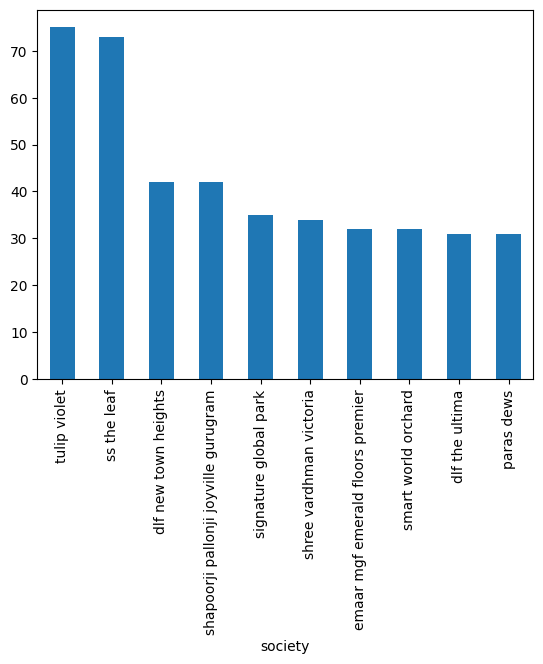

In [12]:
# top 10 society

df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind = 'bar')

In [13]:
df['society'].isnull().sum()

np.int64(1)

In [14]:
df[df['society'].isnull()]

# a lot of data is missing in the row. But lets keep it for now

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
3124,flat,NaN,sector 78,0.6,3692.0,1625.14,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,NaN


Observations
- around 13% properties have 'independent' society tag
- around 72 societies have 50% of the properties and the remaining (around 600) societies contain the remaining 50%
    - More than 100: only 1 society has listing more than 100
    - Bewteen 50 and 100 : only 2 societies have listings between 50 and 100
    - Bewteeen 10 and 50: 92 societies fall in the range of 10 and 49
    - Less than 10 but more than 1 : 272 societies have listed less than 10 and more than 1
    - very low(1): signinifcant number 301 socities have just 1 listing

### sector

In [15]:
df['sector'].value_counts()

sector
sector 47     232
sector 37     114
sector 85     108
sector 102    107
sector 70     104
             ... 
sector 30       5
sector 80       5
sector 3a       4
sector 27       3
sector 73       3
Name: count, Length: 95, dtype: int64

In [16]:
# merge sectors like sector 3a, sector 8c to their parent sector

df['sector'] = df['sector'].str.replace(r'([0-9]+)[a-zA-Z]$', r'\1', regex=True)

In [17]:
df['sector'].value_counts()

sector
sector 47     232
sector 37     114
sector 85     108
sector 102    107
sector 70     104
             ... 
sector 21       6
sector 30       5
sector 80       5
sector 27       3
sector 73       3
Name: count, Length: 94, dtype: int64

In [18]:
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    'Very High (>100)': (sector_counts > 100).sum(),
    'High (50-100)': ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    'Avg (10-49)': ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    'Low (2-9)': ((sector_counts > 1) & (sector_counts < 10)).sum(),
    'Very Low (=1)': (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(5),
 'High (50-100)': np.int64(23),
 'Avg (10-49)': np.int64(52),
 'Low (2-9)': np.int64(14),
 'Very Low (=1)': np.int64(0)}

Observation 
- Total of 94 unique sectors
- Frequency:
    - more than 100 listings: 5 sectors
    - listings between 50 and 100: 23 sectors
    - listings between 10 and 50 : 52 sectors
    - listings between 1 and 10: 14 sectors
    - no sector with just 1 listing

### Price column

In [19]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,house,independent,sector 105,0.60,11102.0,540.44,Plot area 60(50.17 sq.m.),8,4,3,...,NaN,540.0,NaN,0,0,0,0,0,1,13.0
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,...,1735.00,NaN,1500.0,0,0,0,0,0,1,16.0
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.80,Super Built up area 2588.79(240.51 sq.m.),3,3,3,...,2588.83,NaN,NaN,1,0,0,0,0,0,40.0
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,...,1741.00,NaN,1218.0,0,0,0,1,0,1,117.0
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,...,1404.00,NaN,1200.0,0,0,0,0,1,0,9.0


In [20]:
df['price_in_cr'].isnull().sum()

np.int64(17)

In [21]:
df['price_in_cr'].describe()

count    3647.000000
mean        2.538870
std         2.984105
min         0.080000
25%         0.950000
50%         1.540000
75%         2.750000
max        31.500000
Name: price_in_cr, dtype: float64

<Axes: xlabel='price_in_cr', ylabel='Count'>

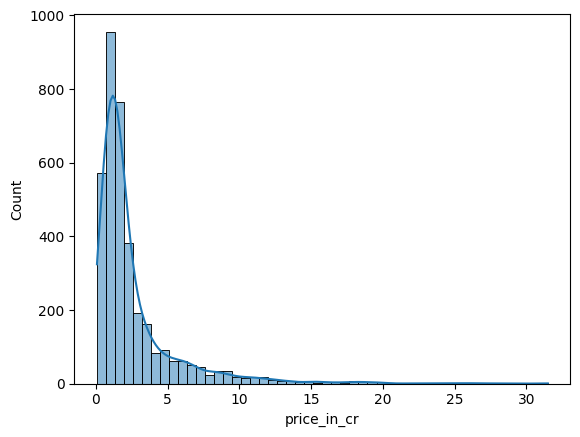

In [22]:
sns.histplot(df['price_in_cr'], kde = True, bins = 50)

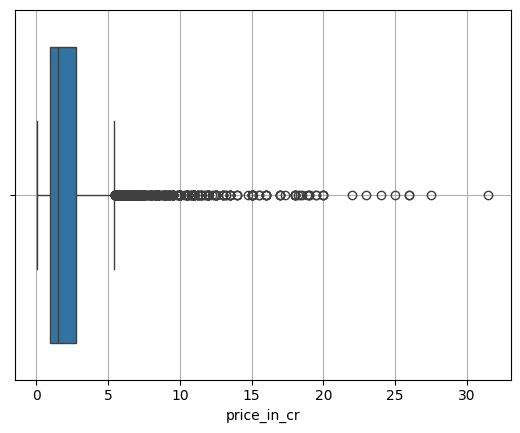

In [23]:
sns.boxplot(x = df['price_in_cr'])
plt.grid()

In [24]:
df[df['price_in_cr'] > 5].shape

(447, 23)

Observations
- 17 missing values 
- Descriptive stats:
    - mean lies around 2.5
    - standard deviation of 2.9 suggest that there is large variability in the data
    - lowest priced property is around 0.08 crores.
    - Price range : 0.08 crores to 31.5 crores
    - IQR range = price range between 25th and 75th percentile : 0.95 to 2.75
- Visualisation:
    - Histogram and kde plot suggest that the data is right skewed. It contains most properties on lower end of the price range (5 crores) but few properties whose prices are too high (beyon 10 crores).
    - Box plot shows potential outliers. Possibly, properties with more than 10 crore price could be considered outliers. 
    - A total of 447 Properties with more than 5 cr valuation

In [25]:
# skewness and kurtosis

skewness = df['price_in_cr'].skew()
kurtosis = df['price_in_cr'].kurt()

print(skewness, kurtosis)

3.274836995069041 14.890167946204766


- Highly positively skewed in line with histogram
- High kurtosis (>3) suggest heavier tails means the presence of many outliers

In [26]:
# Quantile analysis

quantiles = df['price_in_cr'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.316
Name: price_in_cr, dtype: float64

- 1% properties are below 0.25 cr
- 5% properties are priced beloe 0.37 cr
- 95% properties are priced below 8.5 cr
- 99% properties are below 15.31. Can be considered outliers

In [27]:
df[df['price_in_cr'] > 15].shape

(38, 23)

In [28]:
# using IQR method to check outliers

Q1 = df['price_in_cr'].quantile(0.25)
Q3 = df['price_in_cr'].quantile(0.75)
IQR = Q3 - Q1

print(IQR)

lower_range = Q1 - 1.5*IQR
upper_range = Q3 + 1.5*IQR

print(lower_range, upper_range)

1.8
-1.7500000000000002 5.45


In [29]:
outliers = df[df['price_in_cr'] > 5.45]

outliers['price_in_cr'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price_in_cr, dtype: float64

- very high number of outliers. 425 properties seem like outliers based on IQR method. Will keep them for now. 
- Desc Statistics of outliers:
    - mean price of outlier properties is 9.2 cr
    - prices range from 5.4 to 31.5
    - 50% outlier properties are prices below 8 cr

<Axes: xlabel='price_in_cr'>

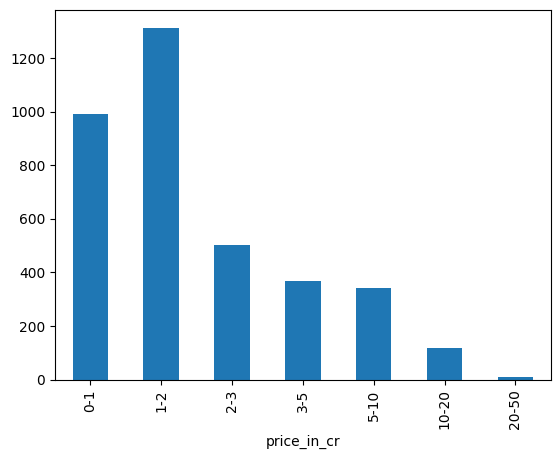

In [30]:
# price bins

bins = [0, 1, 2, 3, 5, 10, 20, 50]
bins_labels = ['0-1', '1-2', '2-3', '3-5', '5-10', '10-20', '20-50']

pd.cut(df['price_in_cr'], bins = bins, labels = bins_labels, right = False).value_counts().sort_index().plot(kind = 'bar')

- highest number of listings are priced between 1-2 crs
- very few properties with price above 10 cr

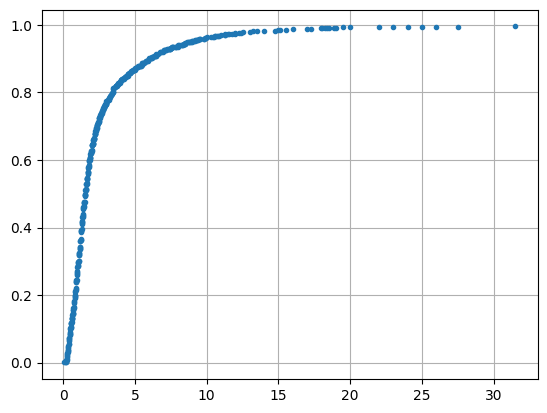

In [31]:
# ecdf plot 
ecdf = df['price_in_cr'].value_counts().sort_index().cumsum()/len(df['price_in_cr'])
plt.plot(ecdf.index, ecdf, marker = '.', linestyle= 'none')
plt.grid()

In [32]:
df['price_in_cr'].quantile(0.875)

np.float64(5.0)

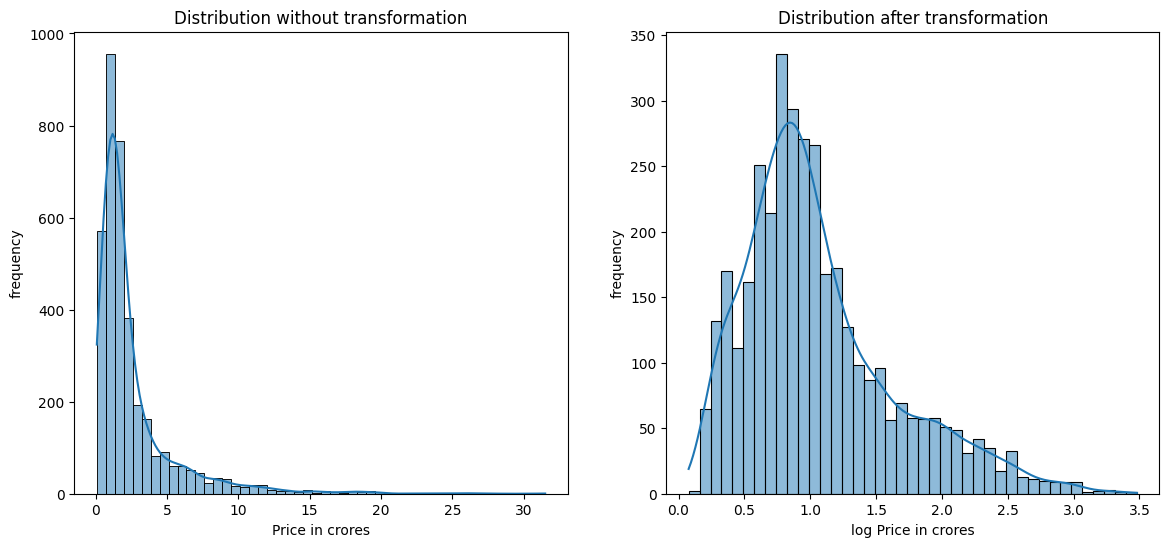

In [33]:
# log transformation on price column
plt.figure(figsize=(14, 6))

plt.subplot(1,2,1)
sns.histplot(df['price_in_cr'], kde = True, bins = 50)
plt.xlabel('Price in crores')
plt.ylabel('frequency')
plt.title('Distribution without transformation')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price_in_cr']), kde = True)
plt.xlabel('log Price in crores')
plt.ylabel('frequency')
plt.title('Distribution after transformation')

plt.show()

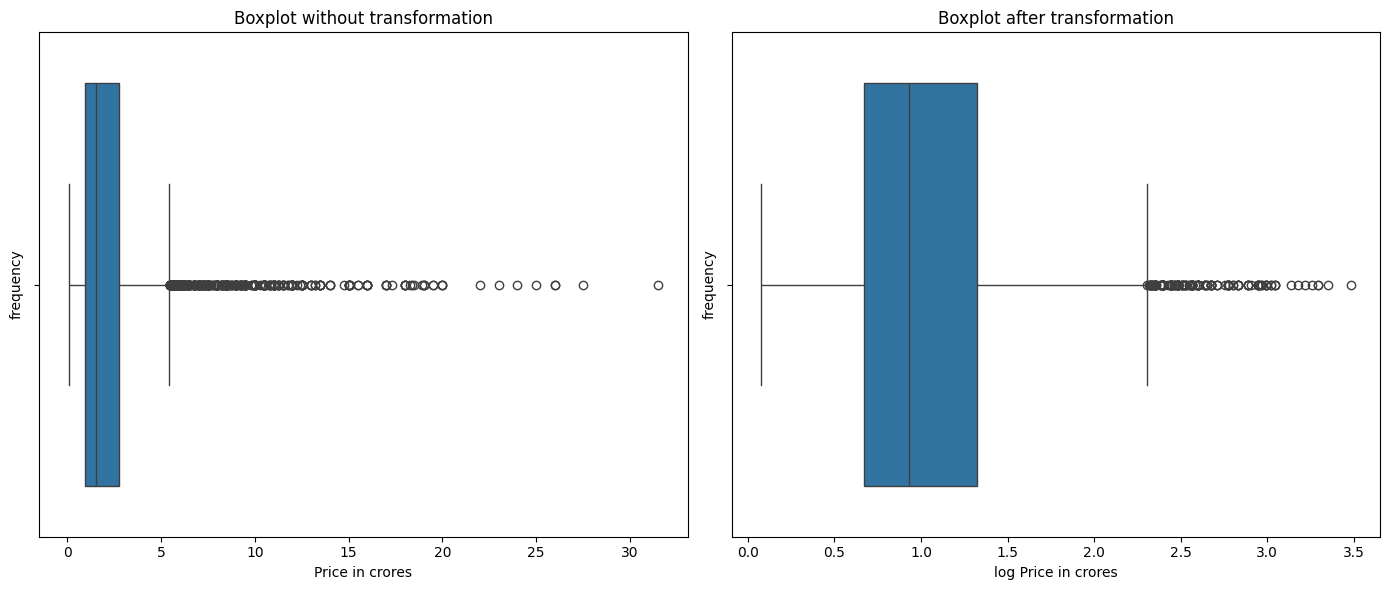

In [34]:
# log transformation and ploting box plot for price column
plt.figure(figsize=(14, 6))

plt.subplot(1,2,1)
sns.boxplot(x = df['price_in_cr'])
plt.xlabel('Price in crores')
plt.ylabel('frequency')
plt.title('Boxplot without transformation')

plt.subplot(1,2,2)
sns.boxplot(x = np.log1p(df['price_in_cr']))
plt.xlabel('log Price in crores')
plt.ylabel('frequency')
plt.title('Boxplot after transformation')

plt.tight_layout()
plt.show()

- log transformation does help with improving the distribution of the data. This will help in getting good results with models which rely on distribution of the data eg. Linear Regression. log1p is used to avoid negative results and handle 0 values

### price_per_sqft

In [35]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [36]:
df['price_per_sqft'].describe()

count      3647.000000
mean      13920.560461
std       23245.911677
min           4.000000
25%        6839.000000
50%        9025.000000
75%       13888.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

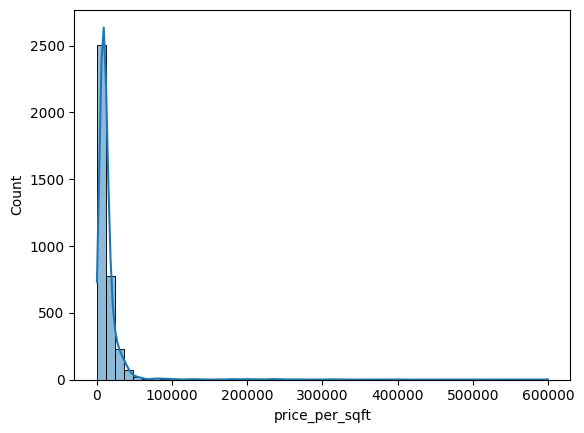

In [37]:
sns.histplot(df['price_per_sqft'], kde = True, bins = 50)

<Axes: xlabel='price_per_sqft'>

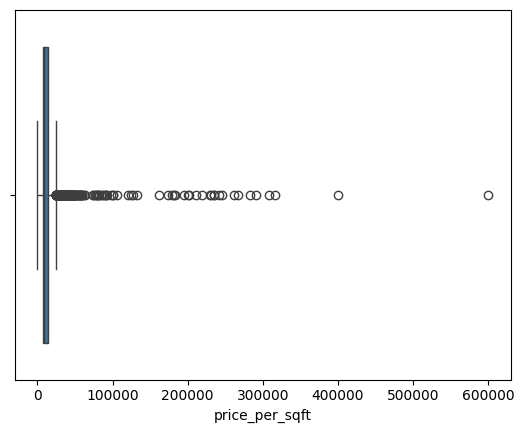

In [38]:
sns.boxplot(x = df['price_per_sqft'])

In [39]:
# skewness and kurtosis

skewness = df['price_per_sqft'].skew()
kurtosis = df['price_per_sqft'].kurt()

print(skewness, kurtosis)

11.421563504349407 186.37842896270308


<Axes: xlabel='price_per_sqft'>

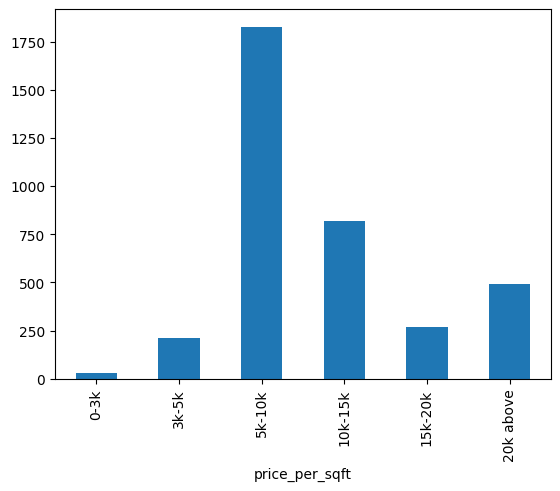

In [40]:
bins = [0, 3000, 5000, 10000, 15000, 20000, 600000]
bins_labels = ['0-3k', '3k-5k', '5k-10k', '10k-15k', '15k-20k', '20k above']

pd.cut(df['price_per_sqft'], bins = bins, labels = bins_labels, right = False).value_counts().sort_index().plot(kind = 'bar')

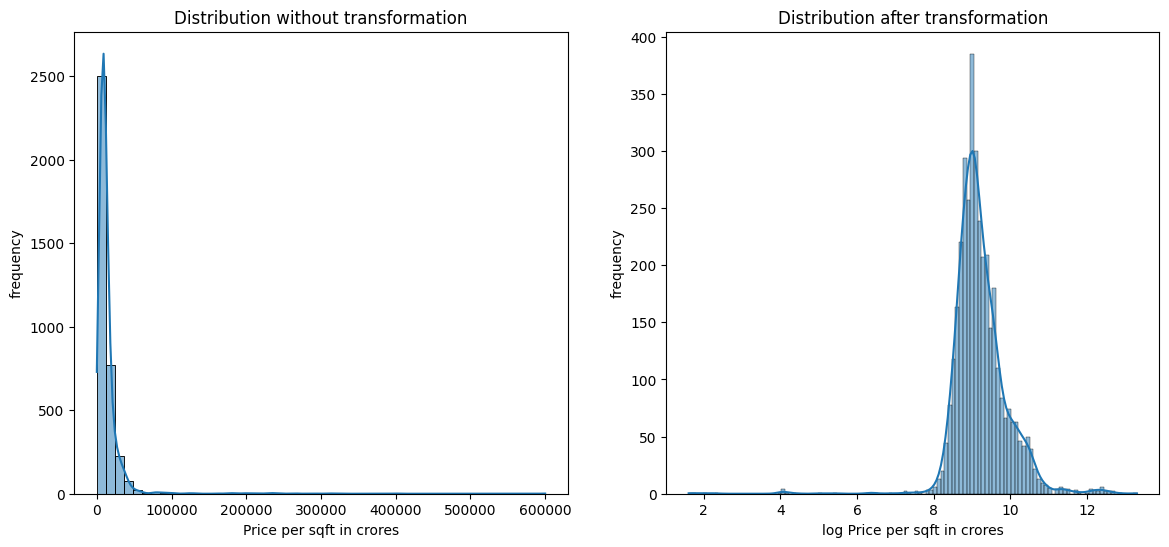

In [41]:
# log transformation on price_per_sqft column
plt.figure(figsize=(14, 6))

plt.subplot(1,2,1)
sns.histplot(df['price_per_sqft'], kde = True, bins = 50)
plt.xlabel('Price per sqft in crores')
plt.ylabel('frequency')
plt.title('Distribution without transformation')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price_per_sqft']), kde = True)
plt.xlabel('log Price per sqft in crores')
plt.ylabel('frequency')
plt.title('Distribution after transformation')

plt.show()

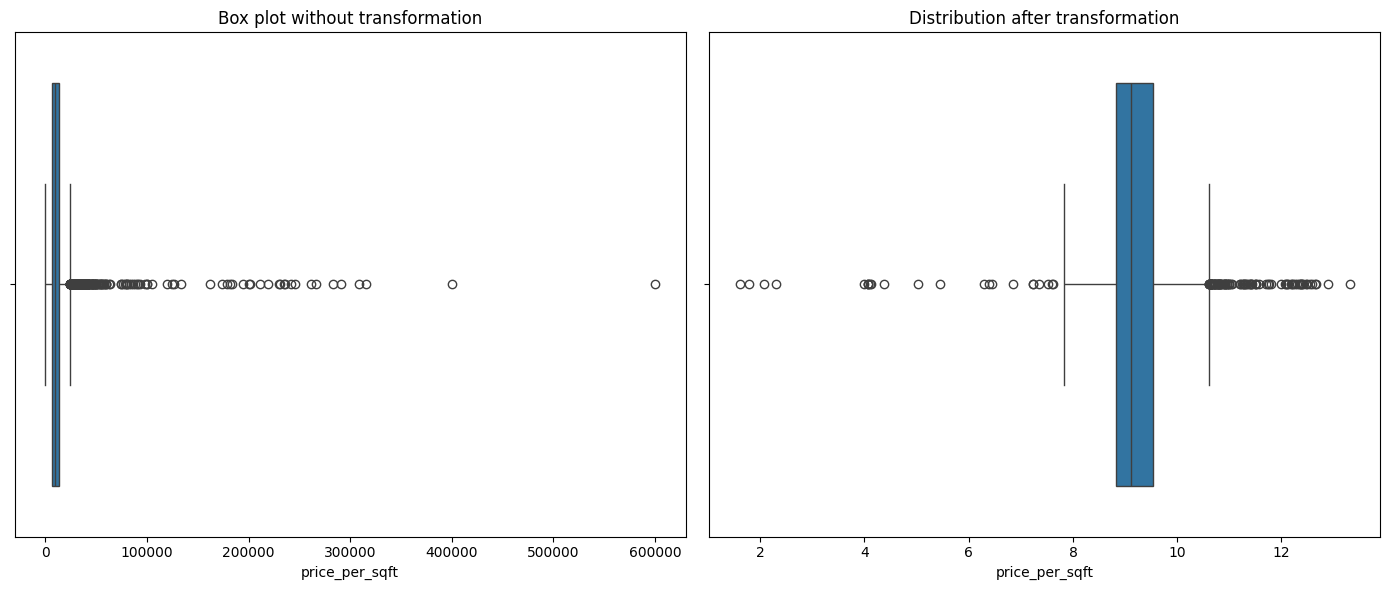

In [42]:
# box plot on log transformed price_per_sqft column
plt.figure(figsize=(14, 6))

plt.subplot(1,2,1)
sns.boxplot(x = df['price_per_sqft'])
plt.title('Box plot without transformation')

plt.subplot(1,2,2)
sns.boxplot(x = np.log1p(df['price_per_sqft']))
plt.title('Distribution after transformation')

plt.tight_layout()
plt.show()

- price per sqft column is highly right skewed. several outliers 
- 17 missing values. Same as price column
- Noticable improvement after log transformation 

### bedRoom

In [43]:
df['bedRoom'].value_counts().sort_index()

bedRoom
1      124
2      938
3     1491
4      658
5      210
6       74
7       28
8       29
9       41
10      19
11       1
12      28
13       4
14       1
16      12
18       2
19       2
20       1
21       1
Name: count, dtype: int64

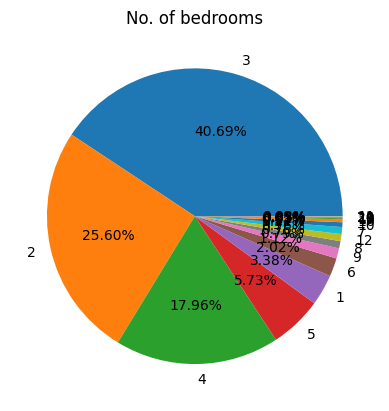

In [44]:
plt.pie(df['bedRoom'].value_counts(), autopct='%0.2f%%', labels=df['bedRoom'].value_counts().index)
plt.title('No. of bedrooms')
plt.show()

<Axes: xlabel='bedRoom'>

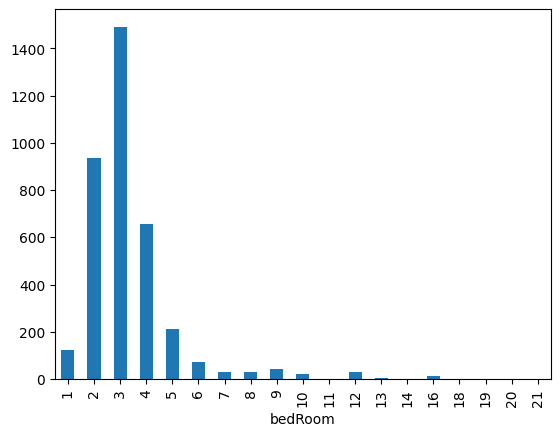

In [45]:
df['bedRoom'].value_counts().sort_index().plot(kind = 'bar')

In [46]:
df['bedRoom'].isnull().sum()

np.int64(0)

- Majority of properties have either 2, 3 or 4 bedrooms
- No missing value

### bathrooms

Text(0, 0.5, 'bathrooms')

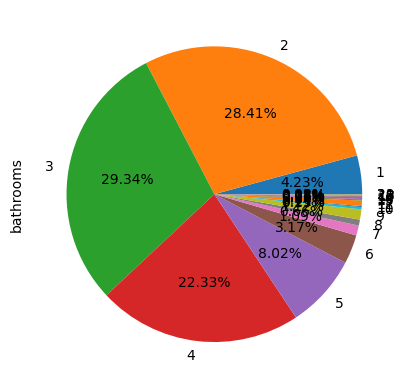

In [47]:
df['bathroom'].value_counts().sort_index().plot(kind = 'pie', autopct = '%0.2f%%')
plt.ylabel('bathrooms')

<Axes: xlabel='bathroom'>

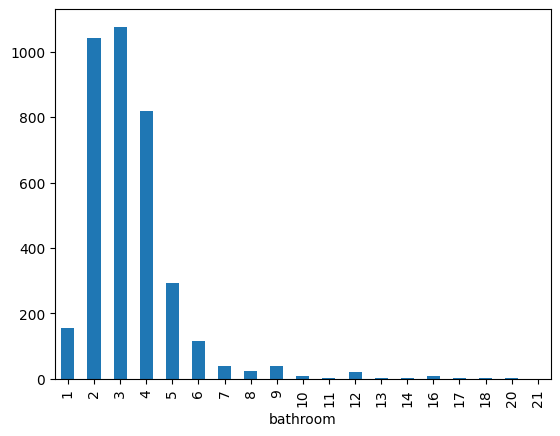

In [48]:
df['bathroom'].value_counts().sort_index().plot(kind = 'bar')

In [49]:
df['bathroom'].isnull().sum()

np.int64(0)

- Most properties have either 2, 3 or 4 bathroom (almost more than 75%)
- No missing values
- High possiblity of multi collienerity with num of bedrooms

### balcony

In [50]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

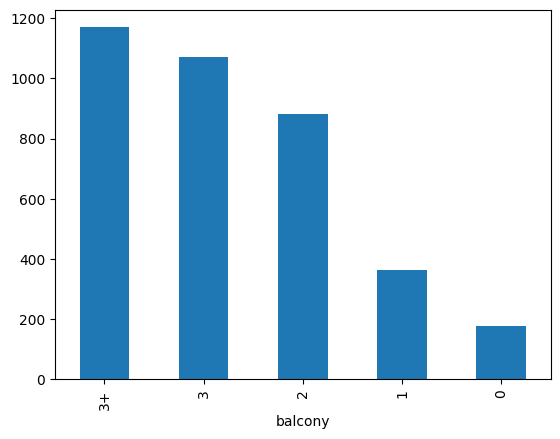

In [51]:
df['balcony'].value_counts().plot(kind = 'bar')

Text(0, 0.5, 'balcony')

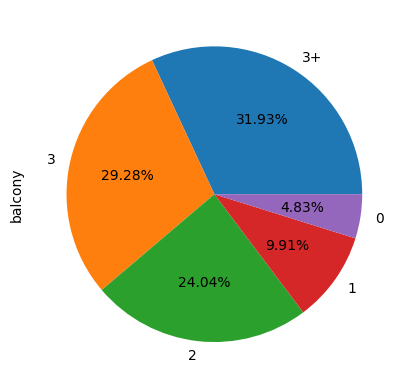

In [52]:
df['balcony'].value_counts().plot(kind = 'pie',autopct = '%0.2f%%')
plt.ylabel('balcony')

- No missing values
- Most properties have 2, 3 or more balconies. Few properties with 1 or no balcony

### floorNum

In [53]:
df['floorNum'].isnull().sum()

np.int64(19)

In [54]:
df['floorNum'].value_counts()

floorNum
3.0     494
2.0     491
1.0     349
4.0     315
8.0     195
6.0     183
10.0    179
7.0     174
5.0     168
9.0     161
12.0    158
0.0     128
11.0    113
14.0    112
15.0     80
16.0     52
17.0     46
13.0     42
18.0     36
19.0     33
20.0     26
21.0     16
23.0     14
22.0     13
24.0     11
25.0      9
27.0      8
30.0      5
26.0      5
33.0      4
28.0      4
29.0      3
31.0      3
43.0      2
34.0      2
32.0      2
35.0      2
39.0      2
45.0      1
40.0      1
38.0      1
51.0      1
44.0      1
Name: count, dtype: int64

<Axes: xlabel='floorNum'>

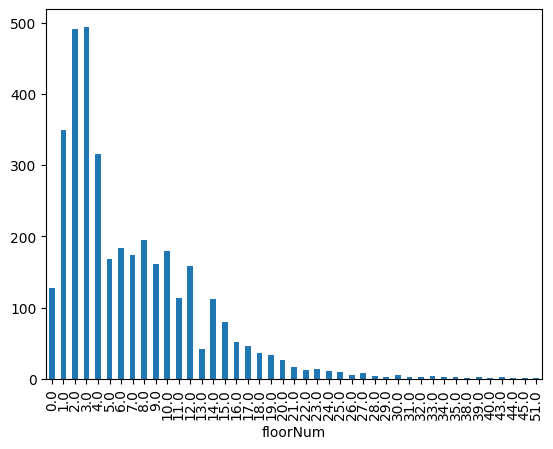

In [55]:
df['floorNum'].value_counts().sort_index().plot(kind = 'bar')


In [56]:
df['floorNum'].describe()

count    3645.000000
mean        6.811248
std         6.017951
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: >

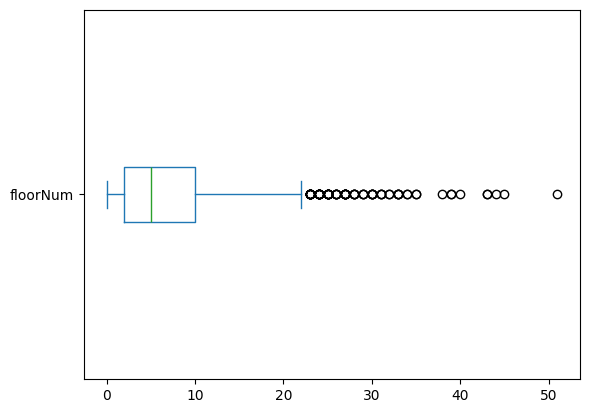

In [57]:
df['floorNum'].plot(kind = 'box', vert = False)

- 19 missing values
- Generally, properties are located on 6th floor (as per the mean)
- Most of properties are are loacted between 0th and 20th floor. 1st to 4th floor being the most common. 2nd and 3rd being most frequent
- Some properties which are located at higher floors but have very low frequency
- box plot shows that most properties are concentrated around lower floors. IQR range roughly lies between 2 and 10 floors
- box plot shows potential outliers

### facing

In [58]:
df['facing'].isnull().sum()

np.int64(1036)

<Axes: xlabel='facing'>

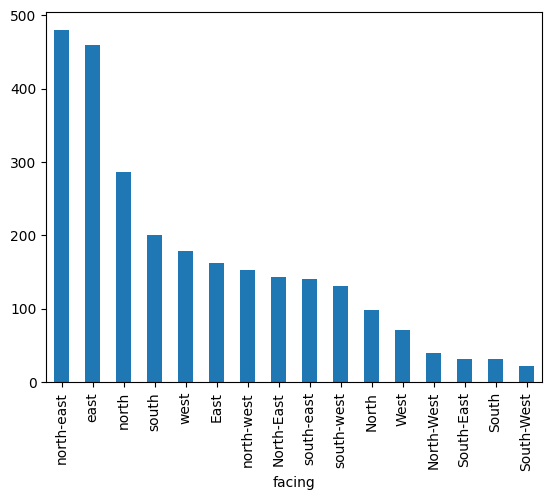

In [59]:
df['facing'].value_counts().plot(kind = 'bar')

<Axes: >

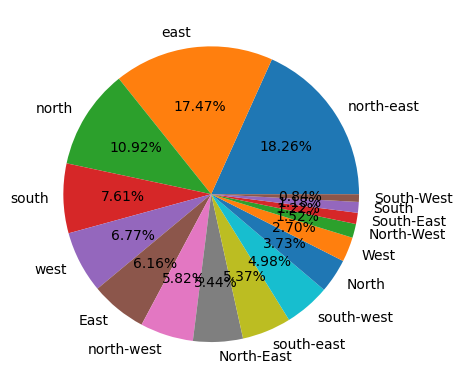

In [60]:
df['facing'].value_counts().plot(kind = 'pie', autopct = '%0.2f%%')

- many missing values
- many properties are facing north east or east. 
- remaining properties are evenly distributed

### agePossession

In [61]:
df['agePossession'].isnull().sum()

np.int64(0)

In [62]:
df['agePossession'].value_counts()

agePossession
relatively new        1643
new                    592
relatively old         559
undefined              306
old                    301
under construction     263
Name: count, dtype: int64

Text(0, 0.5, 'Age of the properties')

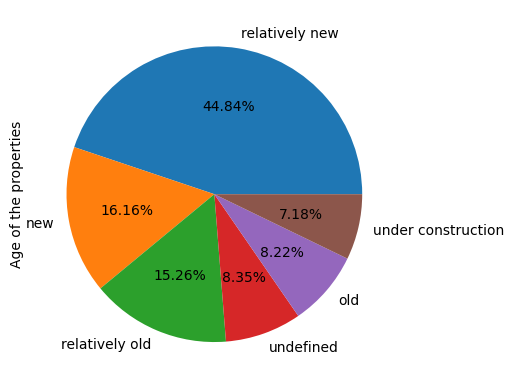

In [63]:
df['agePossession'].value_counts().plot(kind = 'pie', autopct = '%0.2f%%')
plt.ylabel('Age of the properties')

- No missing values
- a lot of properties are new or relatively new properties
- 306 properties' age is not available. 

In [64]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,house,independent,sector 105,0.60,11102.0,540.44,Plot area 60(50.17 sq.m.),8,4,3,...,NaN,540.0,NaN,0,0,0,0,0,1,13.0
1,flat,vatika gurgaon,sector 83,1.18,6801.0,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,...,1735.00,NaN,1500.0,0,0,0,0,0,1,16.0
2,flat,emaar digihomes,sector 62,4.00,14871.0,2689.80,Super Built up area 2588.79(240.51 sq.m.),3,3,3,...,2588.83,NaN,NaN,1,0,0,0,0,0,40.0
3,flat,ss the leaf,sector 85,1.10,6318.0,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,...,1741.00,NaN,1218.0,0,0,0,1,0,1,117.0
4,flat,tarc maceo,sector 91,0.89,6339.0,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,...,1404.00,NaN,1200.0,0,0,0,0,1,0,9.0


### areas (super_built_up_area,	built_up_area, carpet_area)

In [65]:
# super_built_up_area

df['super_built_up_area'].isnull().sum()

np.int64(1792)

In [66]:
df['super_built_up_area'].describe()

count     1872.000000
mean      1924.234092
std        765.591039
min         89.000000
25%       1478.750000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

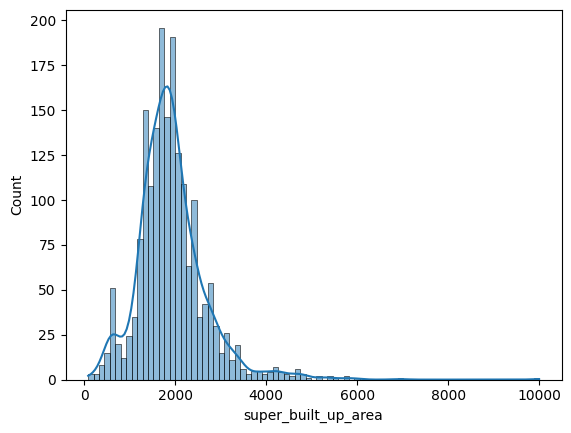

In [67]:
sns.histplot(df['super_built_up_area'], kde = True)

<Axes: xlabel='super_built_up_area'>

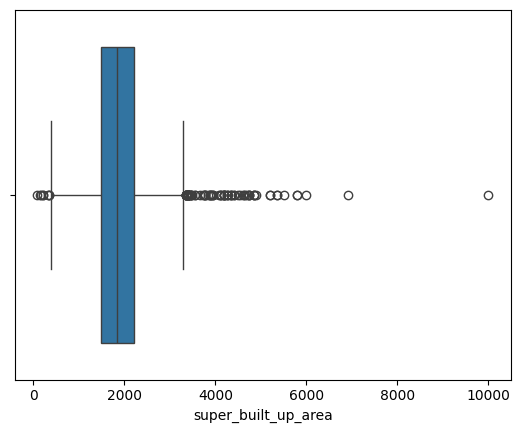

In [68]:
sns.boxplot(x = df['super_built_up_area'])

- Too many missing values (around 1800)
- Right skewed because of some high super built up areas like 10k
- Outliers above 6k, though few in numbers
- Desc stats:
    - avg super built up area lies at 1924,
    - min of 89 super builtup area needs more checks
    - max is 10k which seem outlier

In [69]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1979)

In [70]:
df['built_up_area'].describe()

count      1685.000000
mean       2378.393697
std       17969.558937
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

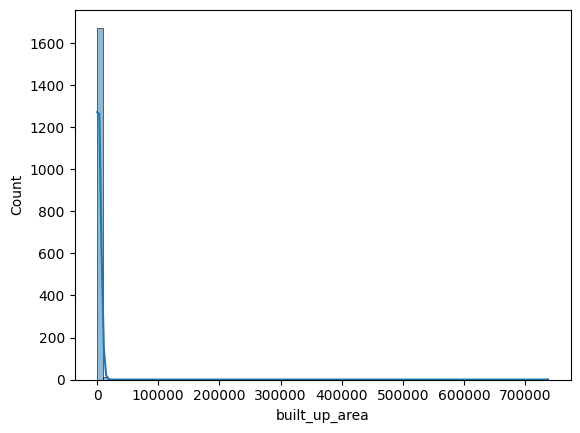

In [71]:
sns.histplot(df['built_up_area'],  kde = True)

<Axes: xlabel='built_up_area'>

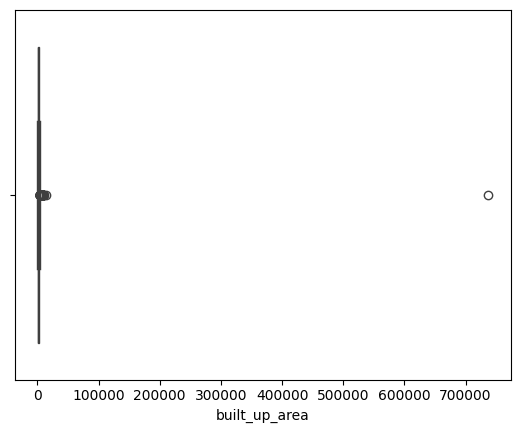

In [72]:
sns.boxplot(x = df['built_up_area'])

<Axes: xlabel='built_up_area', ylabel='Count'>

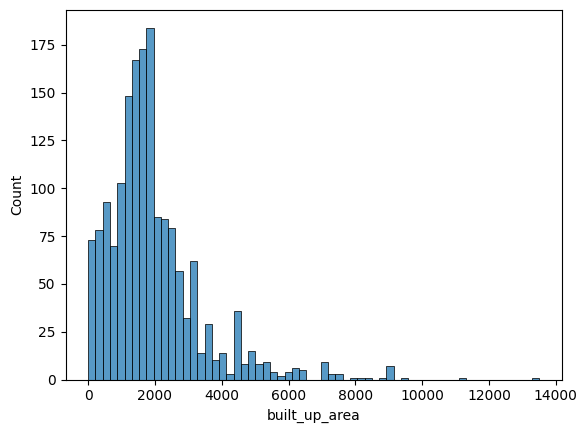

In [73]:
sns.histplot(df[df['built_up_area'] < 700000]['built_up_area'])

- High number of missing values in built up area (around 1980)
- Desc Stats:
    - mean built up area is around 2378 which is higher than super built up area. Needs more investigation
    - 50% or properties have less than 1650 built up area. 
    - min of 2 as built up area is not possible. Outlier there
    - max of 737147 is too high. Outlier or data error. Or possibly the issue is in units
- heavily right skewed

In [74]:
# carpet area

df['carpet_area'].isnull().sum()

np.int64(1797)

In [75]:
df['carpet_area'].describe()

count      1867.000000
mean       2531.295956
std       22830.240275
min          15.000000
25%         845.000000
50%        1300.000000
75%        1784.500000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

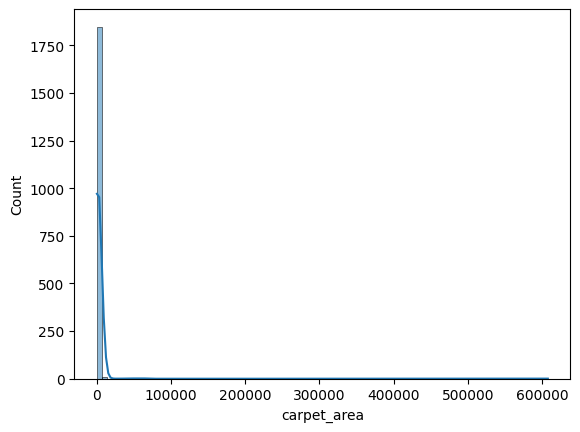

In [76]:
sns.histplot(df['carpet_area'], kde=True)

<Axes: xlabel='carpet_area'>

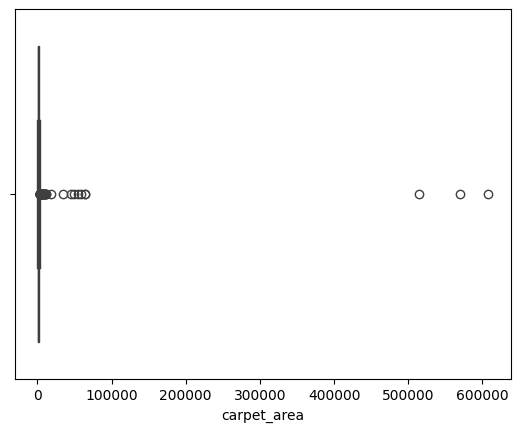

In [77]:
sns.boxplot(x = df['carpet_area'])

- High number of missing values (around 1800)
- Desc stats:
    - mean sits at 2531 (roughly similar to built up area)
    - std is very high. High variation in data
    - 50% properties are below 1300
    - huge difference b/w 75th percentile and max value. max is way too high. Outlier presence
- kde plot show Heavily right skewed.
- box plot confirms the presence of 3 outliers which need more attention

### additional rooms

In [78]:
temp_df = df[['servant room', 'study room', 'pooja room', 'store room', 'others']]

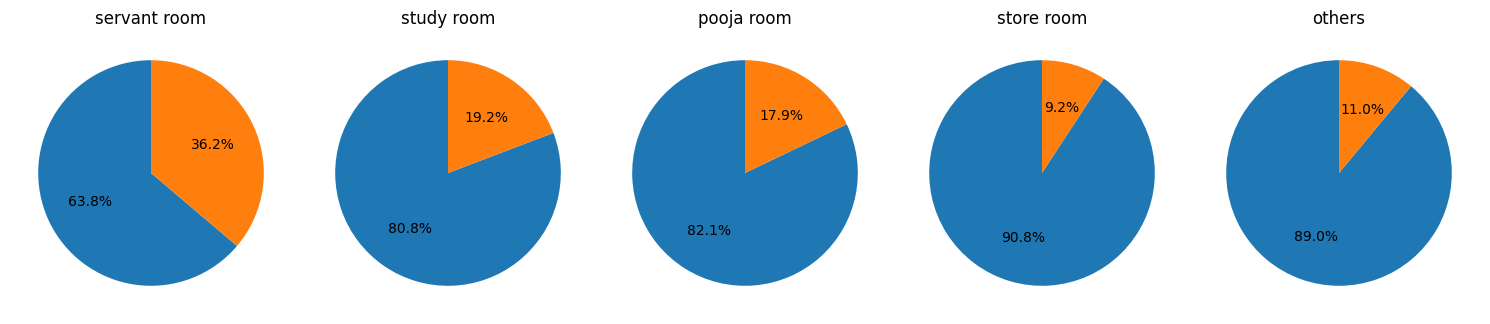

In [87]:
plt.figure(figsize=(15, 8))
for idx, room in enumerate(temp_df.columns):
    plt.subplot(1,5, idx+1)
    plt.pie(temp_df[room].value_counts(), startangle = 90, autopct='%0.1f%%')
    plt.title(f'{room}')

plt.tight_layout()
plt.show()

- highest available category of additional room is servent room. Available in around 36% listings followed by study room and pooja room

In [88]:
df.columns

Index(['property_type', 'society', 'sector', 'price_in_cr', 'price_per_sqft',
       'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum',
       'facing', 'agePossession', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'servant room', 'study room', 'pooja room', 'store room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='str')

### 

### furnishing_type

In [89]:
df['furnishing_type'].isnull().sum()

np.int64(0)

In [95]:
df['furnishing_type'].value_counts()

furnishing_type
1    2391
0    1061
2     212
Name: count, dtype: int64

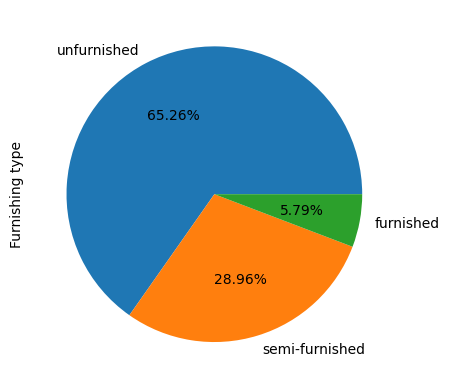

In [97]:
plt.pie(df['furnishing_type'].value_counts(), autopct='%0.2f%%', labels=['unfurnished', 'semi-furnished', 'furnished'])
plt.ylabel('Furnishing type')
plt.show()

- no missing values
    - #1 --> unfurnished
    - #2 --> furnished
    - #0 --> sem-furnished
- majority proprties are unfurnished
- around 5% listings are furnished

### luxury score

In [99]:
df['luxury_score'].isnull().sum()

np.int64(452)

In [100]:
df['luxury_score'].describe()

count    3212.000000
mean       65.024595
std        44.285494
min         2.000000
25%        24.000000
50%        56.000000
75%        96.000000
max       154.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

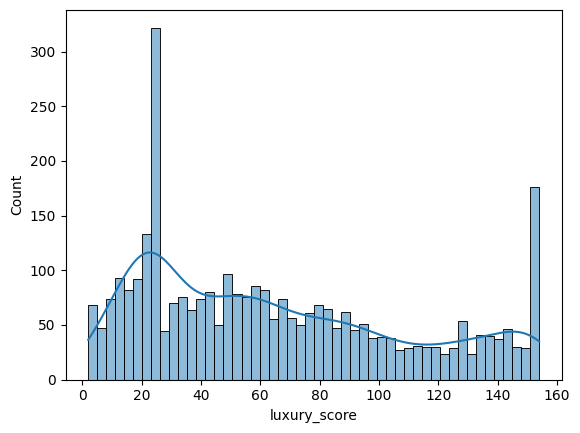

In [102]:
sns.histplot(df['luxury_score'], bins = 50, kde = True)

<Axes: xlabel='luxury_score'>

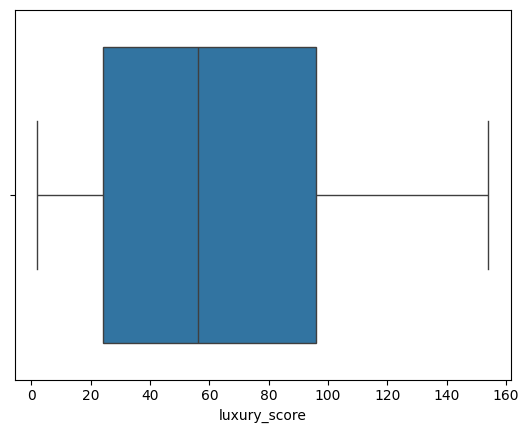

In [104]:
sns.boxplot(x = df['luxury_score'])

- around 450 missing values. This include the properties where features were not available
- Desc stat:
    - mean is 65 and median sits around 56